# A qualitative investigation of locality and anti-locality effects within lossy-context surprisal
This thesis aims to investigate whether or not lossy-context surprisal (Futrell et al., 2021), at least qualitatively, has the requisite mechanisms necessary to explain both locality and anti-locality effects and interactions between them within a coherent framework.

In [2]:
import toylossy
import seaborn as sns
import grammars
from nltk.grammar import PCFG
import expdata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## The syntactic complexity of Russian relative clauses

In [3]:
pcfg_russian = PCFG.fromstring(
    grammars.gen_russian_grammar_exp2(
        p_src = 0.58, 
        p_src_local = 0.94, 
        p_orc_local = 0.36,
        p_one_arg = 0.92, 
        p_adj_interveners = 0.26, 
        p_one_adj = 0.86
    )
)

del_rate = 0.4
max_retention_probability = 1-del_rate
rate_falloff = 0.9

# model_russian = toylossy.SimpleDeletionModel(pcfg_russian, del_rate)
model_russian = toylossy.ProgressiveNoiseModel(pcfg_russian, max_retention_probability, rate_falloff)

The parameters were chosen in accordance with the corpus study results of Levy et al. (2013), as reported in Table 1 (p. 467). $p(\text{SRC)}=\frac{163}{279}\approx 0.58$, $p(\text{SRC}_\text{Local})=\frac{154}{163}\approx 0.94$, $p(\text{ORC}_\text{Local})=\frac{42}{116}\approx 0.36$.

The other probabilities were calculated using Universal Dependencies (see the very end of this notebook for the used queries). The probability of the verb being ditransitive is given as 

### Experiment 1
In this experiment, local and non-local RC configurations were tested to ascertain the reading time at the verb, first and foremost. The results were the following:

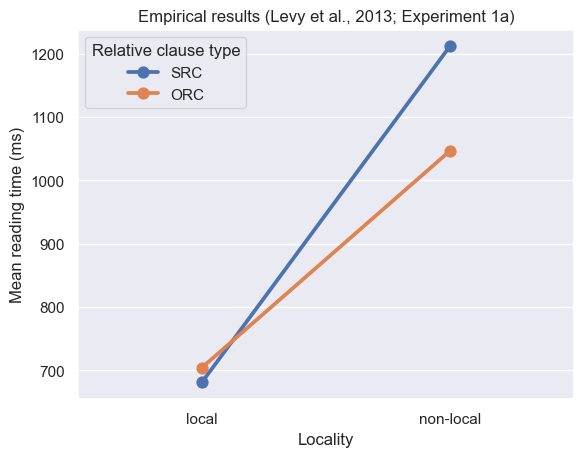

In [4]:
sns.set_theme()

sns.pointplot(expdata.levy_exp1a_verb,
              x = "Locality", 
              y = "Mean reading time (ms)", 
              hue = "Relative clause type"
).set_title("Empirical results (Levy et al., 2013; Experiment 1a)");

We run the model with the parameters assigned as above and get the following plot:

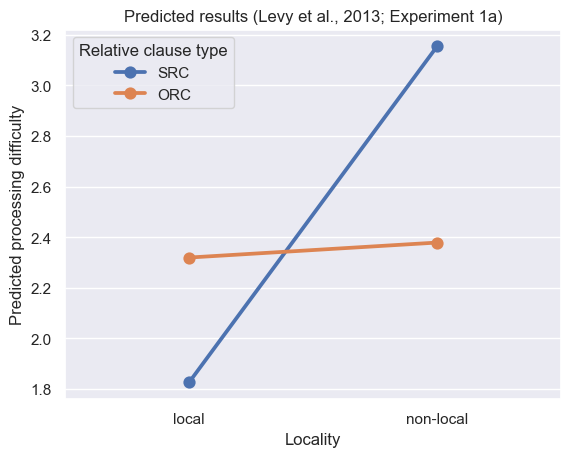

In [5]:
src_local = model_russian.calculate_processing_difficulty("RPNom V".split())
src_non_local = model_russian.calculate_processing_difficulty("RPNom DO V".split())

orc_local = model_russian.calculate_processing_difficulty("RPAcc V".split())
orc_non_local = model_russian.calculate_processing_difficulty("RPAcc Subj V".split(), False)

sim_data_exp1 = pd.DataFrame({
    "Predicted processing difficulty": [src_local, src_non_local, orc_local, orc_non_local],
    "Relative clause type": ["SRC", "SRC", "ORC", "ORC"],
    "Locality": ["local", "non-local", "local", "non-local"]
})

sns.pointplot(sim_data_exp1,
              x = "Locality", 
              y = "Predicted processing difficulty", 
              hue = "Relative clause type"
).set_title("Predicted results (Levy et al., 2013; Experiment 1a)");

We can look at how changing `max_retention_probability` and `rate_falloff` influence the difference between local and non-local ORCs.

In [6]:
def gen_diffs(sequence1: list[str], 
              sequence2: list[str],
              pcfg: PCFG,
              max_retention_probabilities: np.array,
              rate_falloffs: np.array):
    diffs = np.zeros((len(max_retention_probabilities), len(rate_falloffs)))
    for (i, max_rp) in enumerate(max_retention_probabilities):
        for (j, rf) in enumerate(rate_falloffs):
            curr_model = toylossy.ProgressiveNoiseModel(pcfg, max_rp, rf)
            diff = curr_model.calculate_processing_difficulty(sequence1) - curr_model.calculate_processing_difficulty(sequence2)
            diffs[i, j] = diff

    return diffs

max_retention_probabilities = np.arange(0.05, 1.05, 0.05)
rate_falloffs = np.arange(0, 1.05, 0.05)

diffs_orcs_russian = gen_diffs("RPAcc Subj V".split(), "RPAcc V".split(), pcfg_russian, max_retention_probabilities, rate_falloffs)

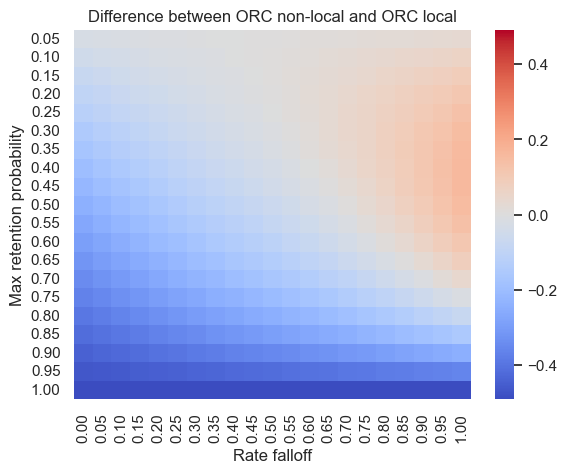

In [7]:
from matplotlib.colors import CenteredNorm

yticklabels = [f"{val:.2f}" for val in max_retention_probabilities]
xticklabels = [f"{val:.2f}" for val in rate_falloffs]
norm = CenteredNorm(vcenter = 0)

sns.heatmap(
    diffs_orcs_russian,
    xticklabels = xticklabels,
    yticklabels = yticklabels,
    cmap = "coolwarm",
    norm = norm
).set(
    title = "Difference between ORC non-local and ORC local",
    xlabel = "Rate falloff",
    ylabel = "Max retention probability"
);

Levy et al. (2013) also looked at the reading time on accusative NPs (in the grammar called 'DO'), and found that these were read slower when placed preverbally than postverbally.

0.4649380867808528


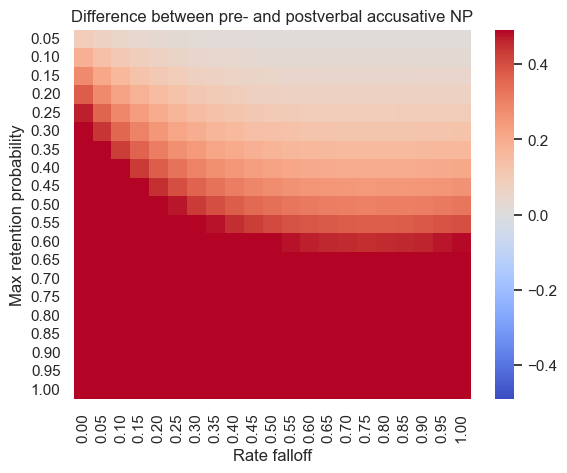

In [8]:
preverbal_acc = model_russian.calculate_processing_difficulty("RPNom DO".split())
postverbal_acc = model_russian.calculate_processing_difficulty("RPNom V DO".split())

diff = preverbal_acc - postverbal_acc
print(diff)

diffs_acc_np_russian = gen_diffs("RPNom DO".split(), "RPNom V DO".split(), pcfg_russian, max_retention_probabilities, rate_falloffs)

sns.heatmap(
    diffs_acc_np_russian,
    xticklabels = xticklabels,
    yticklabels = yticklabels,
    cmap = "coolwarm",
    norm = norm
).set(
    title = "Difference between pre- and postverbal accusative NP",
    xlabel = "Rate falloff",
    ylabel = "Max retention probability"
);

As we can see from this output, the model predicts that preverbal accusative NPs have a higher processing difficulty than postverbal accusative NPs. This is to be expected from an expectation-based standpoint, since, as Levy et al. discuss, local SRC configurations are much more common, meaning a comprehender should expect the word following the nominative relative pronoun to be a verb, not a direct object.

## Experiment 2
The goal of the second experiment was to more directly manipulate the distance between the relative pronoun and the verb. They did this by adding one or two interveners that were either verb arguments (direct object + indirect object) or adjuncts. They results were the following.

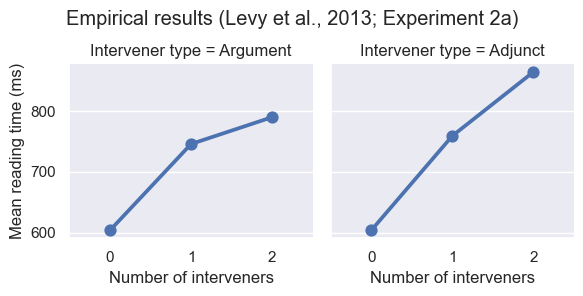

In [9]:
grid = sns.FacetGrid(expdata.levy_exp2a_verb, col = "Intervener type")

grid.map(sns.pointplot, "Number of interveners", "Mean reading time (ms)");
grid.figure.subplots_adjust(top = 0.8);
grid.figure.suptitle("Empirical results (Levy et al., 2013; Experiment 2a)");

For both types of intervener, the reading time rises monotonically at the verb. We can now see what the model predicts for this.

In [10]:
no_intv = model_russian.calculate_processing_difficulty("RPNom V".split())
one_arg = model_russian.calculate_processing_difficulty("RPNom DO V".split())
two_arg = model_russian.calculate_processing_difficulty("RPNom DO IO V".split())

one_adj = model_russian.calculate_processing_difficulty("RPNom Adj V".split())
two_adj = model_russian.calculate_processing_difficulty("RPNom Adj Adj V".split())

sim_data_exp2 = pd.DataFrame({
    "Predicted processing difficulty": [no_intv, one_arg, two_arg, no_intv, one_adj, two_adj],
    "Number of interveners": [0, 1, 2, 0, 1, 2],
    "Intervener type": ["Argument", "Argument", "Argument", "Adjunct", "Adjunct", "Adjunct"]
})

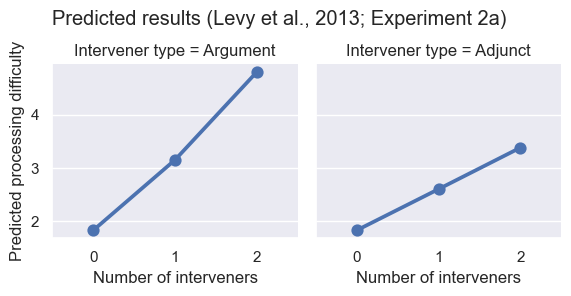

In [11]:
grid = sns.FacetGrid(sim_data_exp2, col = "Intervener type")
grid.map(sns.pointplot, "Number of interveners", "Predicted processing difficulty");
grid.figure.subplots_adjust(top = 0.8);
grid.figure.suptitle("Predicted results (Levy et al., 2013; Experiment 2a)");

We can also have a look at the range of predictable effects.

In [12]:
diffs_arg1_zero = gen_diffs("RPNom DO V".split(), "RPNom V".split(), pcfg_russian, max_retention_probabilities, rate_falloffs)
diffs_arg2_arg1 = gen_diffs("RPNom DO IO V".split(), "RPNom DO V".split(), pcfg_russian, max_retention_probabilities, rate_falloffs)

diffs_adj1_zero = gen_diffs("RPNom Adj V".split(), "RPNom V".split(), pcfg_russian, max_retention_probabilities, rate_falloffs)
diffs_adj2_adj1 = gen_diffs("RPNom Adj Adj V".split(), "RPNom Adj V".split(), pcfg_russian, max_retention_probabilities, rate_falloffs)

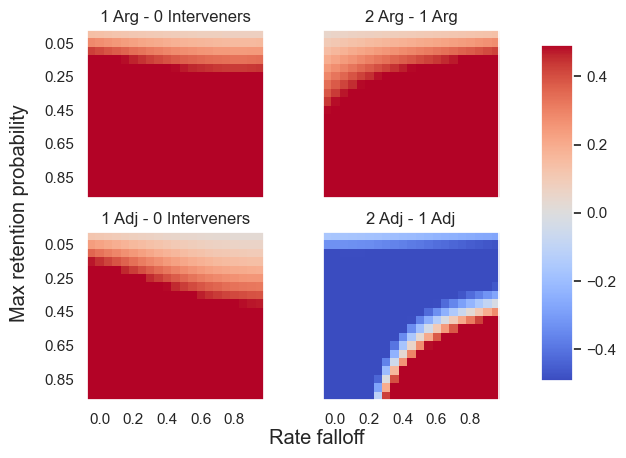

In [13]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)

im = axes[0,0].imshow(diffs_arg1_zero, cmap = "coolwarm", norm = norm)
axes[0,0].grid(False)
axes[0,0].set(
    title = "1 Arg - 0 Interveners",
    xticks = np.arange(1, len(rate_falloffs), 4),
    xticklabels = np.round(np.arange(np.min(rate_falloffs), np.max(rate_falloffs), 0.2), 2),
    yticks = np.arange(1, len(max_retention_probabilities), 4),
    yticklabels = np.round(np.arange(np.min(max_retention_probabilities), np.max(max_retention_probabilities), 0.2), 2)
)

axes[0,1].imshow(diffs_arg2_arg1, cmap = "coolwarm", norm = norm)
axes[0,1].grid(False)
axes[0,1].set(
    title = "2 Arg - 1 Arg",
)

axes[1,0].imshow(diffs_adj1_zero, cmap = "coolwarm", norm = norm)
axes[1,0].grid(False)
axes[1,0].set(
    title = "1 Adj - 0 Interveners",
)

axes[1,1].imshow(diffs_adj2_adj1, cmap = "coolwarm", norm = norm)
axes[1,1].grid(False)
axes[1,1].set(
    title = "2 Adj - 1 Adj",
)

fig.subplots_adjust(right = 0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(im, cax = cbar_ax)

fig.supxlabel("Rate falloff")
fig.supylabel("Max retention probability")

plt.show()

# Strong expectations cancel locality effects: Evidence from Hindi
## Experiment 1
The first experiment was very similar to the first experiment of Levy et al. (2013), where verb locality was crossed with relative clause type. Hindi has some peculiarities: the non-local word order is canonical for both SRCs and ORCs, however, there is a chance that either the direct object or the subject is dropped. This 

In [14]:
pcfg_hindi = PCFG.fromstring(
    grammars.gen_hindi_grammar_exp1(
        p_src = 0.74,
        p_src_local = 0.01,
        p_obj_elision = 0.41,
        p_orc_local = 0.01,
        p_subj_elision = 0.98
    )
)

model_hindi = toylossy.ProgressiveNoiseModel(pcfg_hindi, max_retention_probability, rate_falloff)

The parameters were chosen based on the data from Husain et al. (2014). In a corpus study, the authors found a total of 345 relative clauses with a transitive verb. 248 of these were SRCs and 87 ORCs, giving $p(\text{SRC}) = \frac{248}{345}\approx 0.74$. Of the SRCs, only 2 had the non-canonical local word order, from which we get $p(\text{SRC}_\text{Local})=\frac{2}{248}\approx 0.01$. For ORCs, all 87 had the non-local configuration. In order to estimate $p(\text{ORC}_\text{Local})$ I perform Laplace smoothing by adding 1 to the frequency of both non-local and local ORCs, which gives $p(\text{ORC}_\text{Local})=\frac{1}{89}\approx 0.01$.

The elision probabilities are taken from the sentence completion study that the authors performed. They found in only 4 of 168 instances that the subject was produced in object-extracted relative claueses, giving us $p(\text{Subject elision})=\frac{168-4}{168}=\frac{164}{168}\approx 0.98$. Direct objects were however produced in 100 cases, giving $p(\text{Direct object elision})=\frac{68}{168}\approx 0.41$.

The reading times were as follows at the relative clause verb.

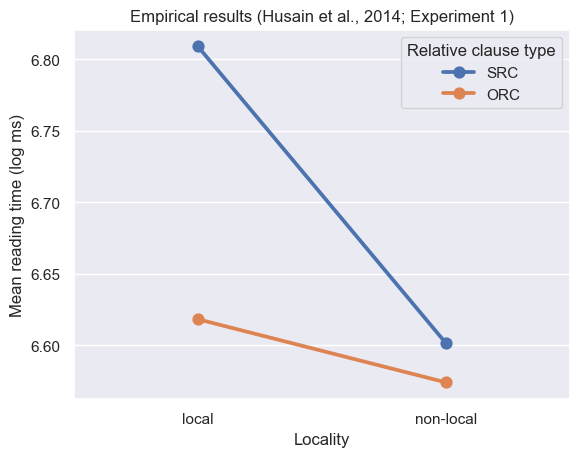

In [15]:
sns.pointplot(expdata.husain_exp1_verb,
              x = "Locality",
              y = "Mean reading time (log ms)",
              hue = "Relative clause type").set_title("Empirical results (Husain et al., 2014; Experiment 1)");

Let's look at the predicted data from the model.

In [16]:
src_local = model_hindi.calculate_processing_difficulty("RPErg V".split())
src_non_local  = model_hindi.calculate_processing_difficulty("RPErg DO V".split())

orc_local = model_hindi.calculate_processing_difficulty("RPAcc V".split())
orc_non_local  = model_hindi.calculate_processing_difficulty("RPAcc Subj V".split())

sim_husain_exp1_verb = pd.DataFrame({
    "Predicted processing difficulty": [src_local, src_non_local, orc_local, orc_non_local],
    "Relative clause type": ["SRC", "SRC", "ORC", "ORC"],
    "Locality": ["local", "non-local", "local", "non-local"]
})

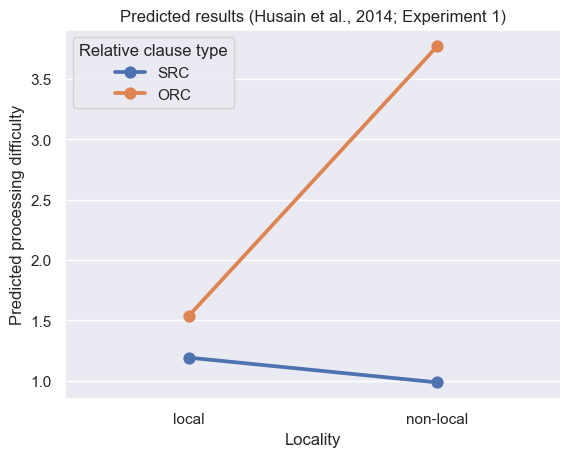

In [17]:
sns.pointplot(sim_husain_exp1_verb,
              x = "Locality",
              y = "Predicted processing difficulty",
              hue = "Relative clause type").set_title("Predicted results (Husain et al., 2014; Experiment 1)");

Here, we can see that the results from the model diverge pretty heavily from the empirical results. This is probably due to the fact that the context $\text{RPAcc Subj}$ is quite rare in the language model, which is in turn caused by the high probability of subject elisions. Although the probability $p(\text{V}\mid \text{RPAcc Subj}) = 1$, the context is heavily downweighted by its low *a priori* probability $p_L(\text{RPAcc Subj})$. Thus, contexts in which a verb do not follow as often are more heavily weighted and thus contribute more to the average probability of the next word being a verb (that is, such contexts are more likely to be reconstructed).

Let's check if there any parameter combinations which could lead to an anti-locality effect in the ORC case.

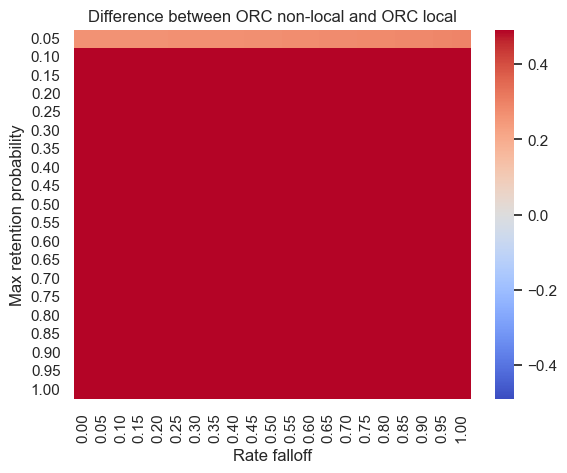

In [18]:
diffs_orcs_hindi = gen_diffs("RPAcc Subj V".split(), "RPacc V".split(), pcfg_hindi, max_retention_probabilities, rate_falloffs)

sns.heatmap(
    diffs_orcs_hindi,
    xticklabels = xticklabels,
    yticklabels = yticklabels,
    cmap = "coolwarm",
    norm = norm
).set(
    title = "Difference between ORC non-local and ORC local",
    xlabel = "Rate falloff",
    ylabel = "Max retention probability"
);

We see that however we pick the parameters, the model will always predict longer reading times at the verb in the non-local case which goes against the observed anti-locality effect. As mentioned above, this seems to be driven by the fact that ORCs very rarely have a subject, which means that the *a priori* probability is very low for the context $p_L(\text{RPAcc Subj})$ is very low.

# Interaction between expectation and locality

Let's look at the data from Experiment 2 of Husain et al. and the study by Safavi et al.

In [20]:
pcfg_persian = PCFG.fromstring(
    grammars.gen_hindi_grammar_exp2(
        0.72,
        0.99,
        0.64,
        0.99,
        0.33
    )
)

model_persian = toylossy.ProgressiveNoiseModel(pcfg_persian, max_retention_probability, rate_falloff)

Let's take a look at what the model predicts.

*Hindi:*

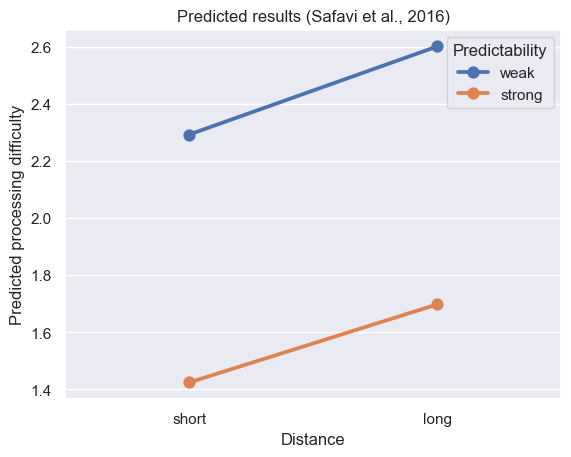

In [21]:
cp_short_persian = model_persian.calculate_processing_difficulty("CPNoun Adj LightVerb".split())
cp_long_persian  = model_persian.calculate_processing_difficulty("CPNoun Adj Adj LightVerb".split())
sp_short_persian = model_persian.calculate_processing_difficulty("SPNoun Adj LightVerb".split())
sp_long_persian  = model_persian.calculate_processing_difficulty("SPNoun Adj Adj LightVerb".split())

sim_data_persian = pd.DataFrame({
    "Predicted processing difficulty": [sp_short_persian, sp_long_persian, cp_short_persian, cp_long_persian],
    "Distance": ["short", "long", "short", "long"],
    "Predictability": ["weak", "weak", "strong", "strong"]
})

sns.pointplot(sim_data_persian,
              x = "Distance",
              y = "Predicted processing difficulty",
              hue = "Predictability").set_title("Predicted results (Safavi et al., 2016)");

# Why not Experiment 1b of Levy et al.?
Although this did show evidence for expectation-based theories, for the sake of constraining the scope of this work I decided to leave it out.

# PML Queries

# Russian
## SRCs


## ORCs
### Local word order

Result: 7

### Non-local word order

Result: 20

$p(\text{ORC}_{\text{Local}})=\frac{7}{27}=0.6$